# Agricultural Land Exposed to Prolonged Droughts

In this tutorial, we combine the drought hazard (here: drought duration) with agricultural land cover data to estimate the area of agricultural land exposed to drought in Central Greece (NUTS2 region EL64). Agricultural drought exposure is a key component of risk assessments for the agricultural sector.

We use two complementary land cover datasets:
- **CORINE Land Cover**: European land cover maps (1990, 2000, 2006, 2012, 2018)
- **Satellite Land Cover**: Global annual satellite-based land cover (1992–2022)

For future projections we assume *persistence*: the most recently observed agricultural fraction is held constant to 2100. In the final section we explore sensitivity to different land use trajectories.

```{admonition} Learning Objectives
:class: tip
By the end of this tutorial, you will understand:
- How to combine drought hazard and agricultural land data to estimate exposure
- How historical agricultural drought exposure has evolved
- How future climate change affects agricultural drought exposure under a persistence land use assumption
- How to visualise compound uncertainty from climate scenarios and land use trajectories
```

```{admonition} Prerequisites
:class: note
This tutorial uses preprocessed CSV data for Central Greece (EL64). See:
- [How-To Guide on Drought Duration](../how-to-guides/drought_duration_ecde.ipynb) for drought data preprocessing
- [How-To Guide on CORINE Land Cover](../how-to-guides/agricultural_land_corine.ipynb) for CORINE preprocessing
- [How-To Guide on Satellite Land Cover](../how-to-guides/agricultural_land_satellite.ipynb) for satellite data preprocessing
```


## Setup


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
from pathlib import Path
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Settings


In [7]:
# Configuration
admin_id = 'EL64'

# Reference period (WMO standard: 1991-2020)
baseline_start = 1991
baseline_end   = 2020

# Paths (relative to the tutorials/ folder)
data_dir           = Path('../data') / admin_id
drought_reanalysis = data_dir / 'drought_hazard' / f'drought_duration_reanalysis_{admin_id}.csv'
drought_proj_path  = data_dir / 'drought_hazard' / f'drought_duration_projections_{admin_id}.csv'
corine_agri_csv    = data_dir / 'corine_land_cover' / 'land_cover_categories.csv'
satellite_agri_csv = data_dir / 'satellite_land_cover' / f'agricultural_land_fraction_{admin_id}.csv'

print(f'Region: {admin_id} (Central Greece)')
print('\nData files:')
for f in [drought_reanalysis, drought_proj_path, corine_agri_csv, satellite_agri_csv]:
    print(f'  {f}')


Region: EL64 (Central Greece)

Data files:
  ../data/EL64/drought_hazard/drought_duration_reanalysis_EL64.csv
  ../data/EL64/drought_hazard/drought_duration_projections_EL64.csv
  ../data/EL64/corine_land_cover/land_cover_categories.csv
  ../data/EL64/satellite_land_cover/agricultural_land_fraction_EL64.csv


## Load Data


In [8]:
# Drought reanalysis
drought_hist_df = pd.read_csv(drought_reanalysis)
drought_hist_df['time'] = pd.to_datetime(drought_hist_df['time'])
drought_hist_df['year'] = drought_hist_df['time'].dt.year

# Drought projections
drought_proj_df = pd.read_csv(drought_proj_path)
drought_proj_df['time'] = pd.to_datetime(drought_proj_df['time'])
drought_proj_df['year'] = drought_proj_df['time'].dt.year

print(f'Drought reanalysis : {drought_hist_df["year"].min()}-{drought_hist_df["year"].max()}')
print(f'Drought projections: {drought_proj_df["year"].min()}-{drought_proj_df["year"].max()}')
print(f'Climate models     : {drought_proj_df["model"].nunique()}')
print(f'Scenarios          : {sorted(drought_proj_df["scenario"].unique())}')


Drought reanalysis : 1940-2023
Drought projections: 1950-2100
Climate models     : 18
Scenarios          : ['RCP4_5', 'RCP8_5']


In [9]:
# CORINE land cover (5 snapshot years; 'agricultural' column in %)
df_corine = pd.read_csv(corine_agri_csv)
df_corine['ag_fraction'] = df_corine['agricultural'] / 100.0

# Satellite land cover (annual 1992-2022; ag_fraction already in 0-1)
df_satellite = pd.read_csv(satellite_agri_csv)

print('CORINE land cover (snapshot years):')
print(df_corine[['year', 'agricultural', 'ag_fraction']].to_string(index=False))
print(f'\nSatellite land cover: {int(df_satellite["year"].min())}-{int(df_satellite["year"].max())} '
      f'({len(df_satellite)} years)')
print(f'  Latest ag_fraction: {df_satellite["ag_fraction"].iloc[-1]:.4f}')


CORINE land cover (snapshot years):
 year  agricultural  ag_fraction
 1990     33.279219     0.332792
 2000     33.257153     0.332572
 2006     32.446728     0.324467
 2012     31.755714     0.317557
 2018     31.745346     0.317453

Satellite land cover: 1992-2022 (31 years)
  Latest ag_fraction: 0.2769


## Part 1: Historical Agricultural Drought Exposure

We estimate historical agricultural drought exposure as:

$$\text{exposure}(t) = \text{drought duration}(t) \times \text{agricultural fraction}(t)$$

where drought duration comes from ERA5 reanalysis and the agricultural fraction from each land cover dataset. The result is an **agricultural drought exposure index** in *months yr⁻¹ × fraction*, representing the drought-weighted share of the region under agricultural use in a given year.

Because CORINE provides only five snapshot years, we **forward-fill** the fraction between snapshots — consistent with the persistence assumption used in the projections (Part 2).


In [10]:
# Build a full annual CORINE series by forward-filling the 5 snapshot values
all_hist_years = pd.DataFrame({'year': range(drought_hist_df['year'].min(),
                                             drought_hist_df['year'].max() + 1)})
corine_annual = all_hist_years.merge(df_corine[['year', 'ag_fraction']], on='year', how='left')
corine_annual['ag_fraction'] = corine_annual['ag_fraction'].ffill()

# Merge with drought reanalysis
hist_corine = drought_hist_df[['year', 'dmd']].merge(corine_annual, on='year', how='inner')
hist_corine['exposure'] = hist_corine['dmd'] * hist_corine['ag_fraction']

hist_satellite = drought_hist_df[['year', 'dmd']].merge(
    df_satellite[['year', 'ag_fraction']], on='year', how='inner')
hist_satellite['exposure'] = hist_satellite['dmd'] * hist_satellite['ag_fraction']

bl_corine    = hist_corine[hist_corine['year'].between(baseline_start, baseline_end)]
bl_satellite = hist_satellite[hist_satellite['year'].between(baseline_start, baseline_end)]

print(f'Historical CORINE exposure   : {hist_corine["year"].min()}-{hist_corine["year"].max()}')
print(f'Historical satellite exposure: {hist_satellite["year"].min()}-{hist_satellite["year"].max()}')
print(f'\nBaseline ({baseline_start}-{baseline_end}) mean exposure:')
print(f'  CORINE   : {bl_corine["exposure"].mean():.4f} months/yr\u00b7fraction')
print(f'  Satellite: {bl_satellite["exposure"].mean():.4f} months/yr\u00b7fraction')


Historical CORINE exposure   : 1940-2023
Historical satellite exposure: 1992-2022

Baseline (1991-2020) mean exposure:
  CORINE   : 0.4088 months/yr·fraction
  Satellite: 0.3692 months/yr·fraction


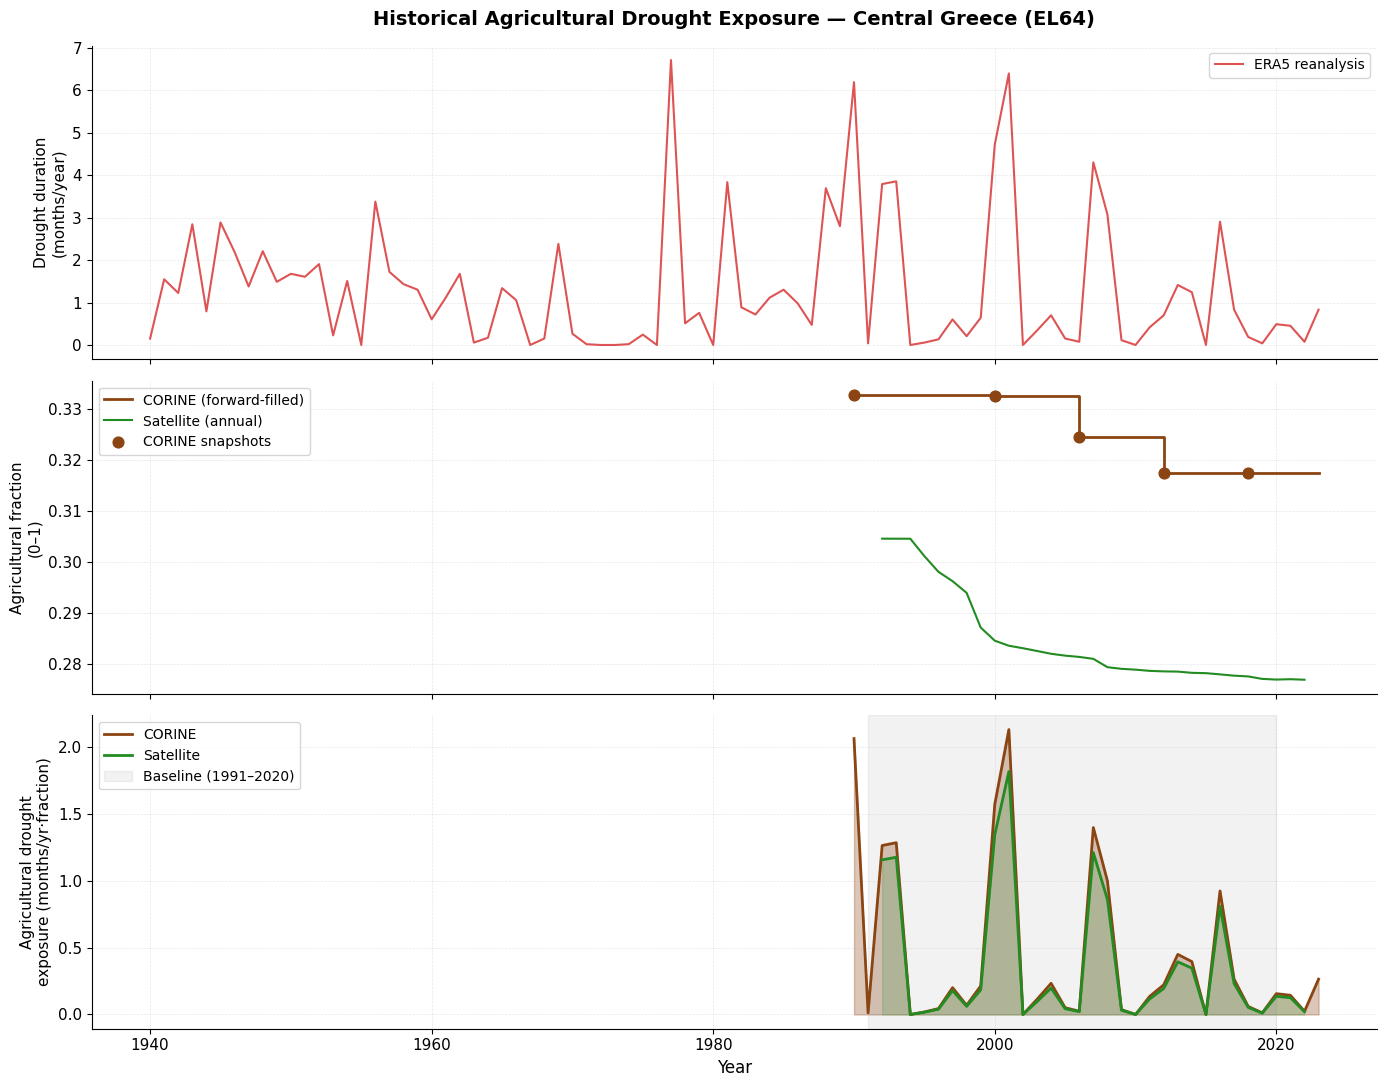

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Panel 1: drought duration
axes[0].plot(hist_corine['year'], hist_corine['dmd'],
             color='#D62828', linewidth=1.5, alpha=0.8, label='ERA5 reanalysis')
axes[0].set_ylabel('Drought duration\n(months/year)', fontsize=11)
axes[0].set_title('Historical Agricultural Drought Exposure \u2014 Central Greece (EL64)',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel 2: agricultural fraction
axes[1].step(hist_corine['year'], hist_corine['ag_fraction'],
             color='#8B4513', linewidth=2, where='post', label='CORINE (forward-filled)')
axes[1].plot(hist_satellite['year'], hist_satellite['ag_fraction'],
             color='#228B22', linewidth=1.5, label='Satellite (annual)')
axes[1].scatter(df_corine['year'], df_corine['ag_fraction'],
                color='#8B4513', s=60, zorder=5, label='CORINE snapshots')
axes[1].set_ylabel('Agricultural fraction\n(0\u20131)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel 3: exposure index
axes[2].fill_between(hist_corine['year'], 0, hist_corine['exposure'],
                     color='#8B4513', alpha=0.3)
axes[2].plot(hist_corine['year'], hist_corine['exposure'],
             color='#8B4513', linewidth=2, label='CORINE')
axes[2].fill_between(hist_satellite['year'], 0, hist_satellite['exposure'],
                     color='#228B22', alpha=0.2)
axes[2].plot(hist_satellite['year'], hist_satellite['exposure'],
             color='#228B22', linewidth=2, label='Satellite')
axes[2].axvspan(baseline_start, baseline_end, color='gray', alpha=0.1,
                label=f'Baseline ({baseline_start}\u2013{baseline_end})')
axes[2].set_ylabel('Agricultural drought\nexposure (months/yr\u00b7fraction)', fontsize=11)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Dataset comparison

Both datasets track the same drought signal but diverge in magnitude of the agricultural fraction (CORINE ~32 %, satellite ~28 % for EL64). This offset is a known consequence of classification differences and spatial resolution rather than an actual land use discrepancy. Despite the offset, the temporal pattern of agricultural drought exposure is consistent across both datasets.


In [12]:
overlap = hist_corine.merge(hist_satellite[['year', 'ag_fraction', 'exposure']],
                            on='year', suffixes=('_corine', '_sat'))

print('Comparison over overlapping years:')
print(f'  Mean CORINE ag fraction   : {overlap["ag_fraction_corine"].mean():.4f}')
print(f'  Mean satellite ag fraction: {overlap["ag_fraction_sat"].mean():.4f}')
diff_pp = (overlap['ag_fraction_corine'] - overlap['ag_fraction_sat']) * 100
print(f'  Mean offset (CORINE - satellite): {diff_pp.mean():+.2f} pp')
print(f'\nBaseline ({baseline_start}-{baseline_end}) mean exposure:')
print(f'  CORINE   : {bl_corine["exposure"].mean():.4f} months/yr\u00b7fraction')
print(f'  Satellite: {bl_satellite["exposure"].mean():.4f} months/yr\u00b7fraction')
ratio = bl_corine['exposure'].mean() / bl_satellite['exposure'].mean()
print(f'  Ratio (CORINE / Satellite): {ratio:.2f}')


Comparison over overlapping years:
  Mean CORINE ag fraction   : 0.3257
  Mean satellite ag fraction: 0.2845
  Mean offset (CORINE - satellite): +4.12 pp

Baseline (1991-2020) mean exposure:
  CORINE   : 0.4088 months/yr·fraction
  Satellite: 0.3692 months/yr·fraction
  Ratio (CORINE / Satellite): 1.11


## Part 2: Future Agricultural Drought Exposure Under Climate Change

We project future exposure by combining:
- **Climate model projections** of drought duration (multiple models × RCP4.5 / RCP8.5)
- **Agricultural fraction** held constant at the latest observed value (**persistence assumption**)

The persistence assumption means no land-use change is assumed after the last observation:
- CORINE: 2018 value (~31.75 %)
- Satellite: 2022 value (~27.69 %)

Any increase in future agricultural drought exposure therefore arises **entirely from climate change**.


In [13]:
# Latest observed agricultural fraction for each dataset
ag_frac_corine    = df_corine['ag_fraction'].iloc[-1]
ag_frac_satellite = df_satellite['ag_fraction'].iloc[-1]
last_corine_year    = int(df_corine['year'].iloc[-1])
last_satellite_year = int(df_satellite['year'].iloc[-1])

print('Persistence values:')
print(f'  CORINE    ({last_corine_year}): {ag_frac_corine:.4f}  ({ag_frac_corine*100:.2f}%)')
print(f'  Satellite ({last_satellite_year}): {ag_frac_satellite:.4f}  ({ag_frac_satellite*100:.2f}%)')


Persistence values:
  CORINE    (2018): 0.3175  (31.75%)
  Satellite (2022): 0.2769  (27.69%)


In [14]:
def make_exposure_stats(drought_df, ag_frac_const, scenario, smooth_window=30):
    """Return per-year exposure statistics for a fixed ag fraction and one RCP scenario.
    Applies a centred rolling mean to each model's drought series before aggregation."""
    df = drought_df[drought_df['scenario'] == scenario].copy()
    df['dmd_smooth'] = df.groupby('model')['dmd'].transform(
        lambda x: x.rolling(window=smooth_window, center=True, min_periods=1).mean()
    )
    df['exposure'] = df['dmd_smooth'] * ag_frac_const
    stats_out = df.groupby('year').agg(
        exposure_median=('exposure', 'median'),
        exposure_p17=('exposure', lambda x: np.percentile(x, 17)),
        exposure_p83=('exposure', lambda x: np.percentile(x, 83)),
        dmd_median=('dmd_smooth', 'median'),
        dmd_p17=('dmd_smooth', lambda x: np.percentile(x, 17)),
        dmd_p83=('dmd_smooth', lambda x: np.percentile(x, 83)),
    ).reset_index()
    return df, stats_out

# CORINE persistence
rcp45_raw_corine, rcp45_stats_corine = make_exposure_stats(drought_proj_df, ag_frac_corine, 'RCP4_5')
rcp85_raw_corine, rcp85_stats_corine = make_exposure_stats(drought_proj_df, ag_frac_corine, 'RCP8_5')

# Satellite persistence
rcp45_raw_sat, rcp45_stats_sat = make_exposure_stats(drought_proj_df, ag_frac_satellite, 'RCP4_5')
rcp85_raw_sat, rcp85_stats_sat = make_exposure_stats(drought_proj_df, ag_frac_satellite, 'RCP8_5')

print('Exposure statistics computed (30-year rolling mean applied to drought series).')
print(f'Projection range: {rcp45_stats_corine["year"].min()}-{rcp45_stats_corine["year"].max()}')


Exposure statistics computed (30-year rolling mean applied to drought series).
Projection range: 1950-2100


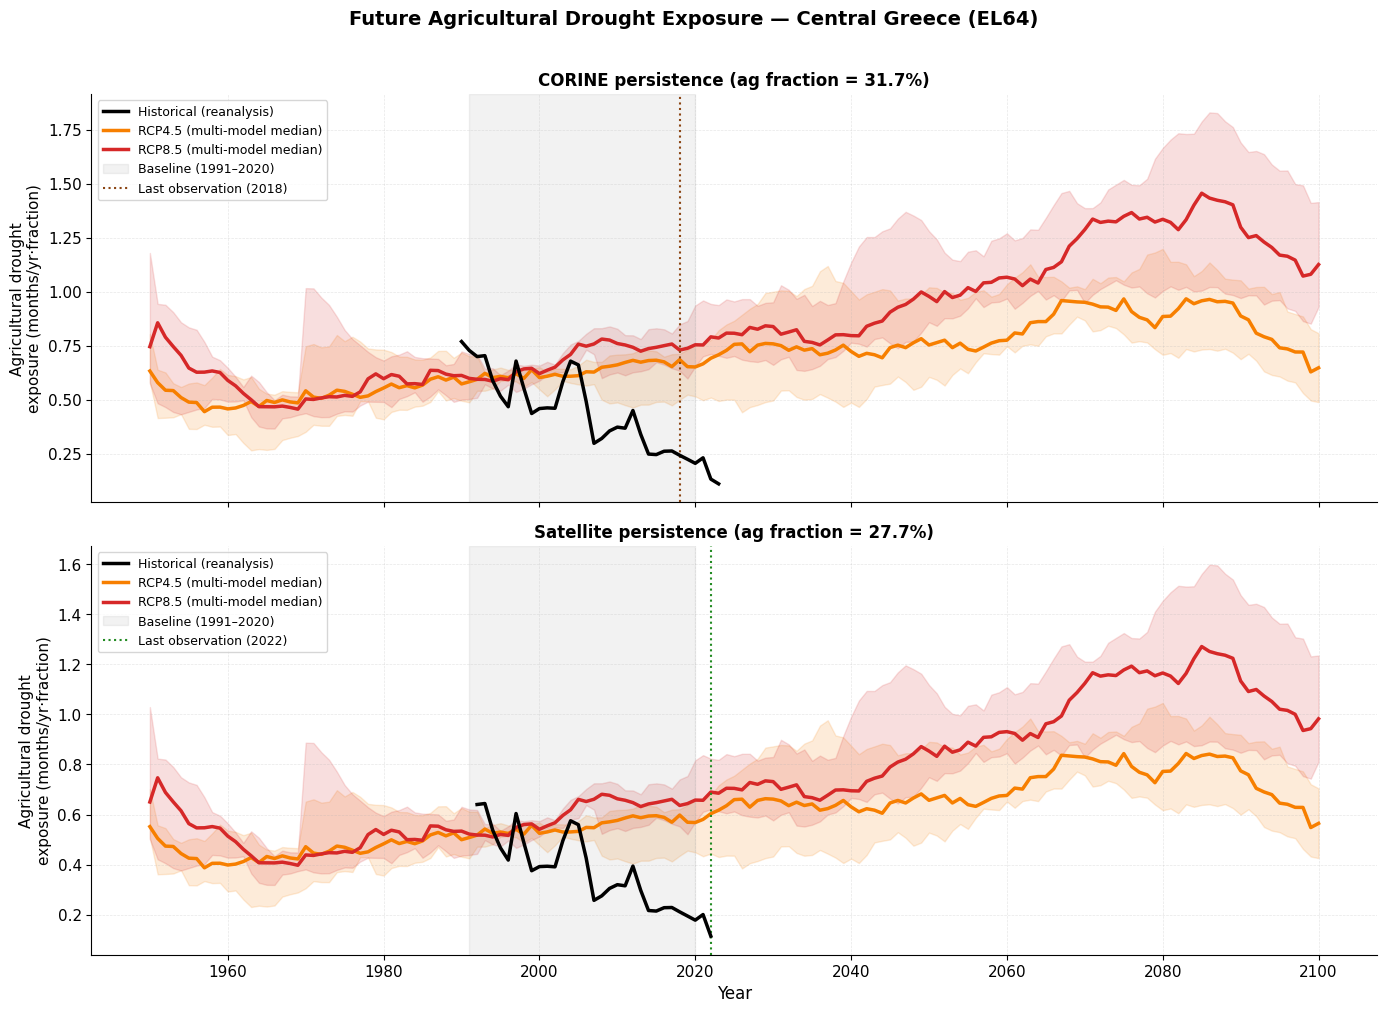

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Smooth historical drought for visual consistency with 30-yr rolling mean projections
hist_smooth = drought_hist_df[['year', 'dmd']].copy()
hist_smooth['dmd'] = hist_smooth['dmd'].rolling(window=10, center=True, min_periods=1).mean()

def add_panel(ax, hist_df, stats45, stats85, hist_label, frac_val, frac_year, frac_color, title):
    ax.plot(hist_df['year'], hist_df['exposure'],
            color='black', linewidth=2.5, label=hist_label, zorder=5)
    for color, stats_df, label in [
        ('#F77F00', stats45, 'RCP4.5 (multi-model median)'),
        ('#D62828', stats85, 'RCP8.5 (multi-model median)'),
    ]:
        ax.plot(stats_df['year'], stats_df['exposure_median'],
                color=color, linewidth=2.5, label=label)
        ax.fill_between(stats_df['year'],
                        stats_df['exposure_p17'], stats_df['exposure_p83'],
                        color=color, alpha=0.15)
    ax.axvspan(baseline_start, baseline_end, color='gray', alpha=0.1,
               label=f'Baseline ({baseline_start}\u2013{baseline_end})')
    ax.axvline(frac_year, color=frac_color, linestyle=':', linewidth=1.5,
               label=f'Last observation ({frac_year})')
    ax.set_ylabel('Agricultural drought\nexposure (months/yr\u00b7fraction)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

hist_corine_smooth = hist_smooth.merge(corine_annual, on='year')
hist_corine_smooth['exposure'] = hist_corine_smooth['dmd'] * hist_corine_smooth['ag_fraction']

hist_sat_smooth = hist_smooth.merge(df_satellite[['year', 'ag_fraction']], on='year', how='inner')
hist_sat_smooth['exposure'] = hist_sat_smooth['dmd'] * hist_sat_smooth['ag_fraction']

add_panel(axes[0], hist_corine_smooth, rcp45_stats_corine, rcp85_stats_corine,
          'Historical (reanalysis)', ag_frac_corine, last_corine_year, '#8B4513',
          f'CORINE persistence (ag fraction = {ag_frac_corine*100:.1f}%)')

add_panel(axes[1], hist_sat_smooth, rcp45_stats_sat, rcp85_stats_sat,
          'Historical (reanalysis)', ag_frac_satellite, last_satellite_year, '#228B22',
          f'Satellite persistence (ag fraction = {ag_frac_satellite*100:.1f}%)')

axes[1].set_xlabel('Year', fontsize=12)
fig.suptitle('Future Agricultural Drought Exposure \u2014 Central Greece (EL64)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Near-, mid-, and long-term changes

We evaluate changes in three 30-year future windows relative to the 1991–2020 baseline:
- **Near-term**: 2021–2050
- **Mid-term**: 2041–2070
- **Long-term**: 2071–2100

Because agricultural fraction is held constant (persistence), changes in exposure factor are driven entirely by changes in drought hazard.


In [16]:
factor_periods = {
    'Near-term':  (2021, 2050),
    'Mid-term':   (2041, 2070),
    'Long-term':  (2071, 2100),
}
period_order = ['Near-term', 'Mid-term', 'Long-term']

# Per-model baseline dmd (average across both scenarios)
baseline_dmd_models = (
    drought_proj_df[drought_proj_df['year'].between(baseline_start, baseline_end)]
    .groupby(['model', 'scenario'])['dmd'].mean()
    .reset_index()
    .groupby('model')['dmd'].mean()
    .reset_index()
    .rename(columns={'dmd': 'baseline_dmd'})
)

period_results = {}
for period_name, (start, end) in factor_periods.items():
    hazard_rcp45, hazard_rcp85 = [], []
    for scenario, h_list in [('RCP4_5', hazard_rcp45), ('RCP8_5', hazard_rcp85)]:
        period_dmd = (
            drought_proj_df[
                drought_proj_df['year'].between(start, end) &
                (drought_proj_df['scenario'] == scenario)
            ]
            .groupby('model')['dmd'].mean().reset_index()
            .rename(columns={'dmd': 'period_dmd'})
        )
        m = period_dmd.merge(baseline_dmd_models, on='model')
        m['hazard_factor'] = m['period_dmd'] / m['baseline_dmd']
        h_list.extend(m['hazard_factor'].values)
    period_results[period_name] = {
        'hazard_rcp45': np.array(hazard_rcp45),
        'hazard_rcp85': np.array(hazard_rcp85),
    }

print('Hazard (= exposure) change factors relative to 1991-2020 baseline:')
for period, res in period_results.items():
    print(f'  {period}:')
    print(f'    RCP4.5 median: {np.median(res["hazard_rcp45"]):.3f}  '
          f'[{np.percentile(res["hazard_rcp45"],17):.3f} - '
          f'{np.percentile(res["hazard_rcp45"],83):.3f}]')
    print(f'    RCP8.5 median: {np.median(res["hazard_rcp85"]):.3f}  '
          f'[{np.percentile(res["hazard_rcp85"],17):.3f} - '
          f'{np.percentile(res["hazard_rcp85"],83):.3f}]')


Hazard (= exposure) change factors relative to 1991-2020 baseline:
  Near-term:
    RCP4.5 median: 1.033  [0.873 - 1.443]
    RCP8.5 median: 1.058  [0.911 - 1.230]
  Mid-term:
    RCP4.5 median: 1.255  [0.994 - 1.415]
    RCP8.5 median: 1.349  [1.300 - 1.623]
  Long-term:
    RCP4.5 median: 1.544  [1.100 - 1.673]
    RCP8.5 median: 1.982  [1.416 - 2.464]


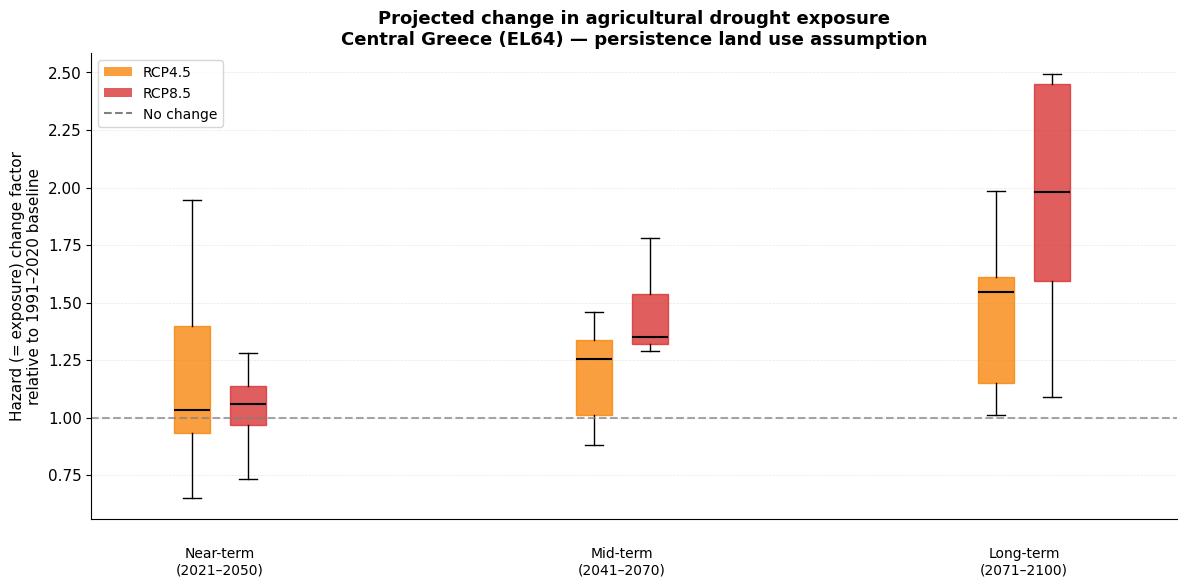

Under the persistence assumption, the exposure change factor equals the hazard change factor.
Boxplot spread shows multi-model uncertainty.


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

data_to_plot, box_colors, x_positions = [], [], []
x = 1.0
for period_name in period_order:
    res = period_results[period_name]
    data_to_plot.extend([res['hazard_rcp45'], res['hazard_rcp85']])
    box_colors.extend(['#F77F00', '#D62828'])
    x_positions.extend([x, x + 0.14])
    x += 1.0

bp = ax.boxplot(
    data_to_plot, patch_artist=True, widths=0.09, showfliers=False,
    medianprops=dict(color='black', linewidth=1.5), positions=x_positions,
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor(color)

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='No change')
y_min, y_max = ax.get_ylim()
ax.set_xlim(0.75, 3.45)
ax.set_xticks([])
for i, period_name in enumerate(period_order):
    start, end = factor_periods[period_name]
    ax.text(1.07 + i, y_min - 0.06 * (y_max - y_min),
            f'{period_name}\n({start}\u2013{end})', ha='center', va='top', fontsize=10)

legend_handles = [
    mpatches.Patch(facecolor='#F77F00', alpha=0.75, label='RCP4.5'),
    mpatches.Patch(facecolor='#D62828', alpha=0.75, label='RCP8.5'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='No change'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=10)
ax.set_ylabel('Hazard (= exposure) change factor\nrelative to 1991\u20132020 baseline', fontsize=11)
ax.set_title(
    'Projected change in agricultural drought exposure\n'
    'Central Greece (EL64) \u2014 persistence land use assumption',
    fontsize=13, fontweight='bold'
)
ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Under the persistence assumption, the exposure change factor equals the hazard change factor.')
print('Boxplot spread shows multi-model uncertainty.')


## Part 3: Uncertainty from Agricultural Land Use Scenarios

The persistence assumption is a simplification. Future agricultural land use may change due to policy, economic, or demographic shifts. To explore sensitivity, we define four CORINE-based land use scenarios and combine each with both climate scenarios:

| Scenario | Agricultural fraction to 2100 |
|---|---|
| **Persistence** | Constant at 2018 CORINE value |
| **Trend** | Linear regression on 1990-2018 CORINE data, extrapolated to 2100 |
| **+10% by 2100** | Linear increase from 2018 value to +10% relative by 2100 |
| **-10% by 2100** | Linear decrease from 2018 value to -10% relative by 2100 |

For each scenario and RCP we compute the multi-model median and plot all eight combinations together, enabling a direct visual comparison of climate-scenario uncertainty versus land-use trajectory uncertainty.


In [18]:
all_proj_years = np.array(sorted(drought_proj_df['year'].unique()))
frac_2018 = ag_frac_corine
year_ref  = last_corine_year   # 2018
year_end  = 2100

# Scenario 1: Persistence
frac_persistence = {yr: frac_2018 for yr in all_proj_years}

# Scenario 2: Linear trend extrapolated from CORINE 1990-2018
slope, intercept, *_ = stats.linregress(df_corine['year'].values, df_corine['ag_fraction'].values)
frac_trend = {yr: max(0.0, slope * yr + intercept) for yr in all_proj_years}

# Scenario 3: +10% relative change by 2100
# Scenario 4: -10% relative change by 2100
frac_plus10, frac_minus10 = {}, {}
for yr in all_proj_years:
    if yr <= year_ref:
        frac_plus10[yr]  = frac_2018
        frac_minus10[yr] = frac_2018
    else:
        t = (yr - year_ref) / (year_end - year_ref)    # linear ramp 0 -> 1
        frac_plus10[yr]  = frac_2018 * (1 + 0.10 * t)
        frac_minus10[yr] = frac_2018 * (1 - 0.10 * t)

scenarios_land = {
    'Persistence':    frac_persistence,
    'Trend':          frac_trend,
    '+10% by 2100':   frac_plus10,
    '-10% by 2100': frac_minus10,
}

print(f'CORINE linear trend: {slope*10:.4f} fraction-points / decade')
print(f'  At 2018: {(slope*2018+intercept)*100:.2f}%  (CORINE actual: {frac_2018*100:.2f}%)')
print(f'\nLand use fractions at year 2100:')
for name, frac_dict in scenarios_land.items():
    print(f'  {name}: {frac_dict[2100]*100:.2f}%')


CORINE linear trend: -0.0065 fraction-points / decade
  At 2018: 31.66%  (CORINE actual: 31.75%)

Land use fractions at year 2100:
  Persistence: 31.75%
  Trend: 26.32%
  +10% by 2100: 34.92%
  -10% by 2100: 28.57%


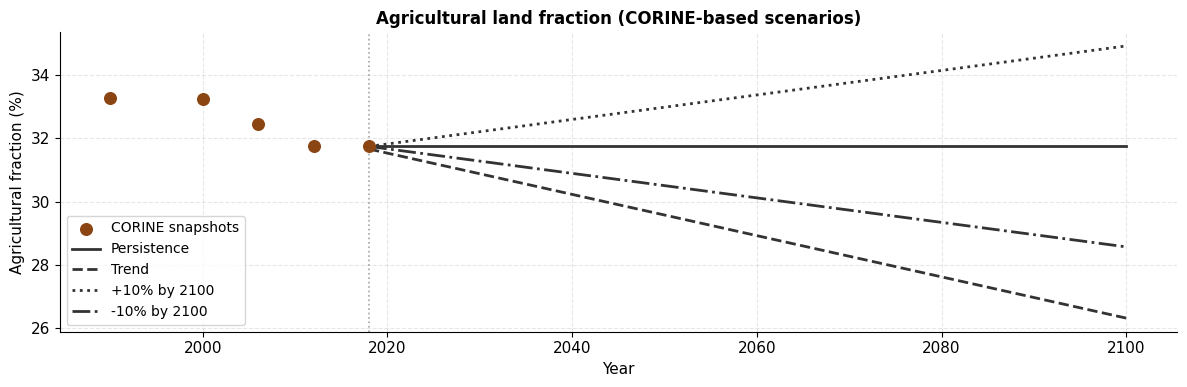

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(df_corine['year'], df_corine['ag_fraction'] * 100,
           color='#8B4513', s=70, zorder=10, label='CORINE snapshots', marker='o')

ls_map = {'Persistence': '-', 'Trend': '--', '+10% by 2100': ':', '-10% by 2100': '-.'}
future_mask = all_proj_years >= year_ref
for name, frac_dict in scenarios_land.items():
    ys = np.array([frac_dict[yr] * 100 for yr in all_proj_years])
    ax.plot(all_proj_years[future_mask], ys[future_mask],
            linestyle=ls_map[name], color='#333333', linewidth=2, label=name)

ax.axvline(year_ref, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_ylabel('Agricultural fraction (%)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_title('Agricultural land fraction (CORINE-based scenarios)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [20]:
def exposure_timeseries(drought_df, scenario_rcp, ag_frac_dict, smooth_window=30):
    """Annual exposure statistics for a time-varying ag fraction and one RCP."""
    df = drought_df[drought_df['scenario'] == scenario_rcp].copy()
    df['dmd_smooth'] = df.groupby('model')['dmd'].transform(
        lambda x: x.rolling(window=smooth_window, center=True, min_periods=1).mean()
    )
    df['ag_frac'] = df['year'].map(ag_frac_dict)
    df['exposure'] = df['dmd_smooth'] * df['ag_frac']
    return df.groupby('year').agg(
        exposure_median=('exposure', 'median'),
        exposure_p17=('exposure', lambda x: np.percentile(x, 17)),
        exposure_p83=('exposure', lambda x: np.percentile(x, 83)),
    ).reset_index()

results_all = {}
for land_name, frac_dict in scenarios_land.items():
    for rcp in ['RCP4_5', 'RCP8_5']:
        results_all[(land_name, rcp)] = exposure_timeseries(drought_proj_df, rcp, frac_dict)

print('Exposure timeseries computed for all 4 land scenarios x 2 RCPs.')


Exposure timeseries computed for all 4 land scenarios x 2 RCPs.


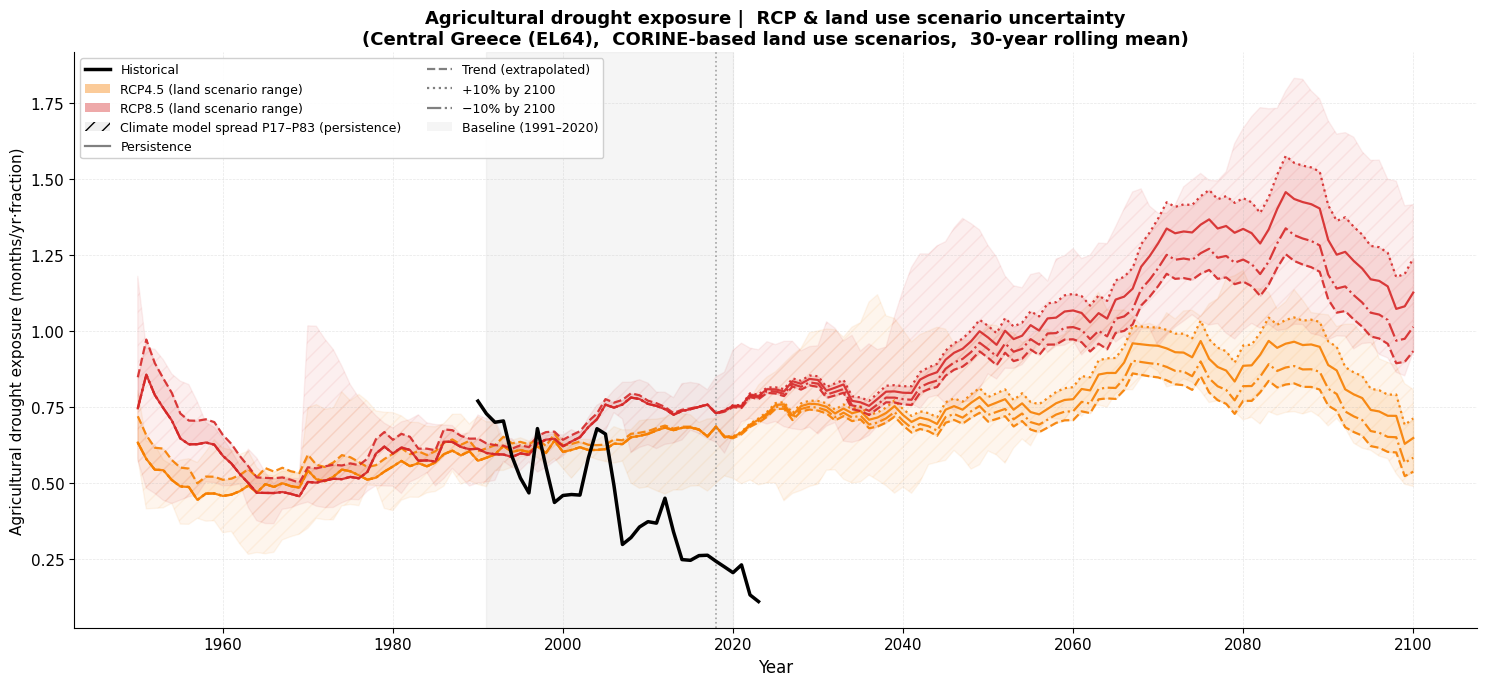


Interpretation:
  Solid / dashed / dotted / dash-dot lines : four land use scenarios.
  Orange vs. red colour family             : RCP4.5 vs. RCP8.5.
  Coloured band (light fill)               : median exposure range across land scenarios for each RCP.
  Hatched band                             : climate model spread (P17-P83) for the persistence scenario.


In [21]:
fig, ax = plt.subplots(figsize=(15, 7))

# Historical reference (smoothed, CORINE forward-fill)
hist_ref = hist_corine.copy()
hist_ref['exposure'] = (
    hist_ref['dmd'].rolling(window=10, center=True, min_periods=1).mean()
    * hist_ref['ag_fraction']
)
ax.plot(hist_ref['year'], hist_ref['exposure'],
        color='black', linewidth=2.5, label='Historical (reanalysis, CORINE)', zorder=10)

rcp_colors = {'RCP4_5': '#F77F00', 'RCP8_5': '#D62828'}
rcp_labels = {'RCP4_5': 'RCP4.5', 'RCP8_5': 'RCP8.5'}
ls_map = {'Persistence': '-', 'Trend': '--', '+10% by 2100': ':', '-10% by 2100': '-.'}

years_proj = results_all[('Persistence', 'RCP4_5')]['year'].values

for rcp in ['RCP4_5', 'RCP8_5']:
    color = rcp_colors[rcp]

    # Envelope spanning all land scenarios (multi-model median range)
    all_medians = np.vstack(
        [results_all[(ls, rcp)].set_index('year')['exposure_median'].reindex(years_proj).values
         for ls in scenarios_land]
    )
    ax.fill_between(years_proj, all_medians.min(axis=0), all_medians.max(axis=0),
                    color=color, alpha=0.12)

    # Climate model spread (P17-P83) for persistence scenario
    ts_pers = results_all[('Persistence', rcp)]
    ax.fill_between(ts_pers['year'], ts_pers['exposure_p17'], ts_pers['exposure_p83'],
                    color=color, alpha=0.07, hatch='//')

    # Individual land scenario lines
    for land_name, ls in ls_map.items():
        ts = results_all[(land_name, rcp)]
        ax.plot(ts['year'], ts['exposure_median'],
                color=color, linewidth=1.6, linestyle=ls, alpha=0.9)

ax.axvspan(baseline_start, baseline_end, color='gray', alpha=0.08)
ax.axvline(year_ref, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Agricultural drought exposure (months/yr\u00b7fraction)', fontsize=11)
ax.set_title(
    'Agricultural drought exposure |  RCP & land use scenario uncertainty\n'
    '(Central Greece (EL64),  CORINE-based land use scenarios,  30-year rolling mean)',
    fontsize=13, fontweight='bold'
)

legend_handles = [
    Line2D([0], [0], color='black', linewidth=2.5, label='Historical'),
    mpatches.Patch(facecolor='#F77F00', alpha=0.4, label='RCP4.5 (land scenario range)'),
    mpatches.Patch(facecolor='#D62828', alpha=0.4, label='RCP8.5 (land scenario range)'),
    mpatches.Patch(facecolor='gray', alpha=0.12, hatch='//', label='Climate model spread P17\u2013P83 (persistence)'),
    Line2D([0], [0], color='gray', linewidth=1.6, linestyle='-',  label='Persistence'),
    Line2D([0], [0], color='gray', linewidth=1.6, linestyle='--', label='Trend (extrapolated)'),
    Line2D([0], [0], color='gray', linewidth=1.6, linestyle=':',  label='+10% by 2100'),
    Line2D([0], [0], color='gray', linewidth=1.6, linestyle='-.', label='\u221210% by 2100'),
    mpatches.Patch(facecolor='gray', alpha=0.08, label=f'Baseline ({baseline_start}\u2013{baseline_end})'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9, frameon=True,
          framealpha=0.92, ncol=2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  Solid / dashed / dotted / dash-dot lines : four land use scenarios.')
print('  Orange vs. red colour family             : RCP4.5 vs. RCP8.5.')
print('  Coloured band (light fill)               : median exposure range across land scenarios for each RCP.')
print('  Hatched band                             : climate model spread (P17-P83) for the persistence scenario.')


## Summary

This tutorial demonstrated how to estimate agricultural drought exposure by combining drought duration with agricultural land cover data.

**Historical exposure**
- Both CORINE and satellite datasets capture the same drought signal but diverge in the absolute agricultural fraction, a known consequence of differences in classification methodology and spatial resolution.
- The temporal pattern of agricultural drought exposure is consistent across both datasets.

**Projected exposure**
- Holding agricultural fraction constant at the latest observed value, any increase in future exposure is driven entirely by climate change.
- RCP8.5 leads to substantially higher agricultural drought exposure than RCP4.5 toward end-of-century.
- Multi-model spread is considerable, highlighting uncertainty in the magnitude of future drought changes.

**Land use scenario uncertainty**
- A +/-10% change in agricultural fraction by 2100 adds meaningful additional uncertainty, especially under RCP4.5 where climate uncertainty is smaller.
- The extrapolated CORINE trend suggests a modest long-term decline in agricultural fraction, partially offsetting increasing drought hazard.
- Emission-scenario choice (RCP4.5 vs. RCP8.5) remains the dominant source of uncertainty by end-of-century.

**Outlook** 
A complete agricultural drought risk assessment would additionally incorporate vulnerability (e.g., irrigation capacity, crop sensitivity, economic dependence on agriculture) and adaptation measures (e.g., drought-resistant crops, irrigation efficiency improvements).
